In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
judged_responses=pd.read_csv("data/responses_judged.csv")

In [3]:
judged_responses.info()

<class 'pandas.DataFrame'>
RangeIndex: 5790 entries, 0 to 5789
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prompt_id              5790 non-null   int64  
 1   prompt                 5790 non-null   str    
 2   layer                  5790 non-null   int64  
 3   alpha                  5790 non-null   float64
 4   response               5790 non-null   str    
 5   judge_raw              5790 non-null   str    
 6   happiness_score        5789 non-null   float64
 7   coherence_score        5789 non-null   float64
 8   happiness_explanation  5789 non-null   str    
 9   coherence_explanation  5789 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 452.5 KB


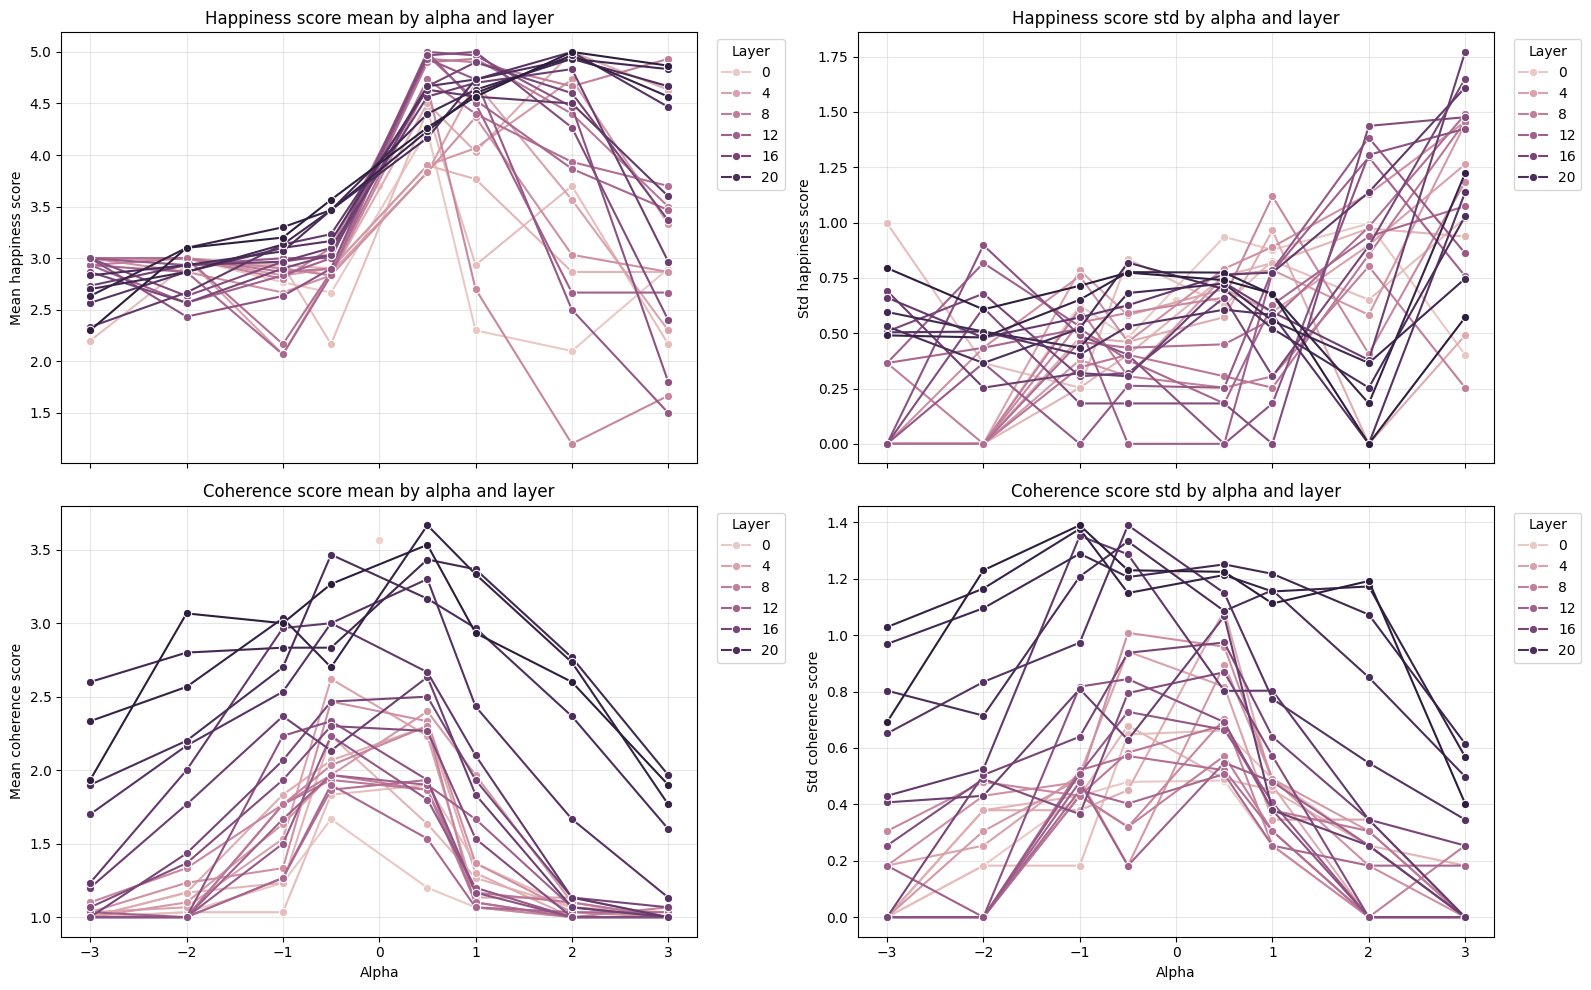

In [4]:
agg = (
    judged_responses
    .groupby(["layer", "alpha"], as_index=False)
    .agg(
        happiness_mean=("happiness_score", "mean"),
        happiness_std=("happiness_score", "std"),
        coherence_mean=("coherence_score", "mean"),
        coherence_std=("coherence_score", "std"),
    )
    .sort_values(["layer", "alpha"])
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

sns.lineplot(data=agg, x="alpha", y="happiness_mean", hue="layer", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Happiness score mean by alpha and layer")
axes[0, 0].set_ylabel("Mean happiness score")

sns.lineplot(data=agg, x="alpha", y="happiness_std", hue="layer", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Happiness score std by alpha and layer")
axes[0, 1].set_ylabel("Std happiness score")

sns.lineplot(data=agg, x="alpha", y="coherence_mean", hue="layer", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Coherence score mean by alpha and layer")
axes[1, 0].set_ylabel("Mean coherence score")
axes[1, 0].set_xlabel("Alpha")

sns.lineplot(data=agg, x="alpha", y="coherence_std", hue="layer", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Coherence score std by alpha and layer")
axes[1, 1].set_ylabel("Std coherence score")
axes[1, 1].set_xlabel("Alpha")

for ax in axes.flat:
    ax.legend(title="Layer", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

Best happiness combination:
layer             3.0
alpha             2.0
happiness_mean    5.0
happiness_std     0.0

Best coherence combination:
layer             22.000000
alpha              0.500000
coherence_mean     3.666667
coherence_std      1.212957

Top 10 combinations by balanced score:
 layer  alpha  happiness_mean  coherence_mean  combined_score
    22    0.5        4.233333        3.666667        0.899123
    21    1.0        4.633333        3.366667        0.895504
    19    0.5        4.666667        3.300000        0.887390
    22    1.0        4.600000        3.333333        0.884868
    23    0.5        4.266667        3.533333        0.878509
    21    0.5        4.400000        3.433333        0.877303
    20    1.0        4.733333        2.966667        0.833662
    21    2.0        4.933333        2.766667        0.822478
    22    2.0        4.966667        2.733333        0.820614
    23    1.0        4.566667        2.933333        0.805482


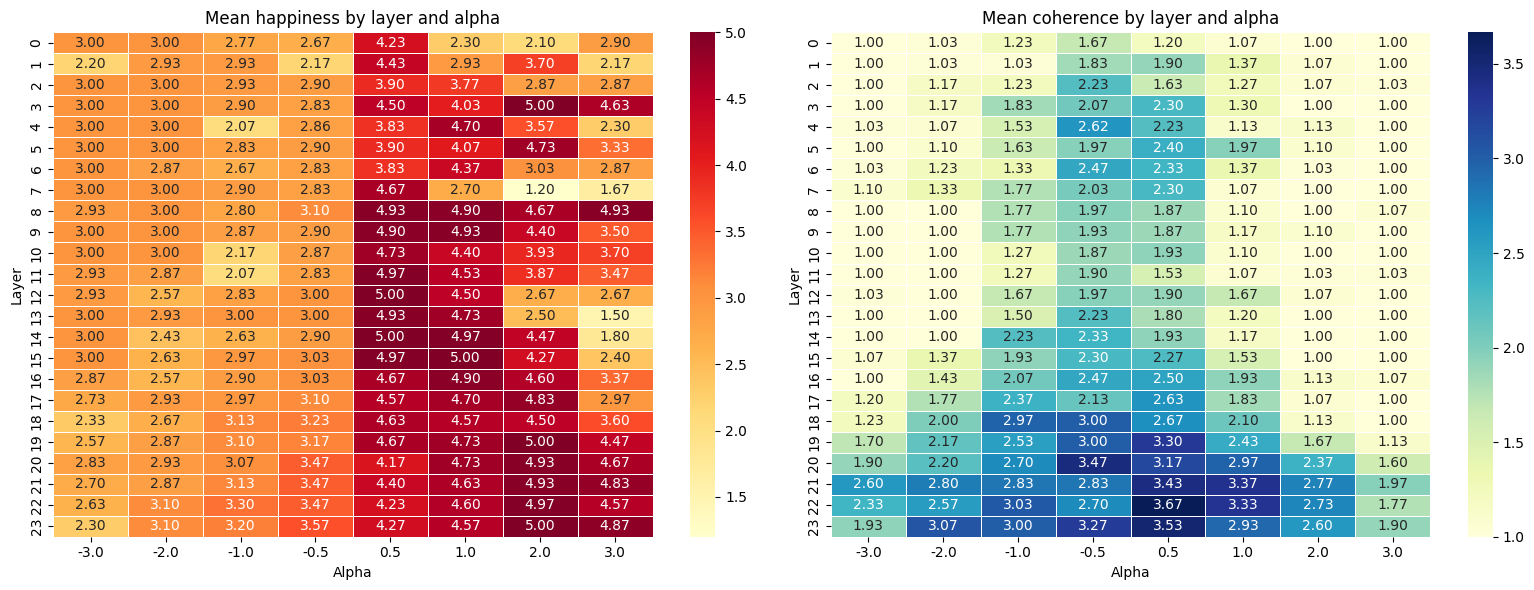

In [5]:
plot_agg = agg[agg["alpha"] != 0].copy()

happiness_grid = plot_agg.pivot(index="layer", columns="alpha", values="happiness_mean")
coherence_grid = plot_agg.pivot(index="layer", columns="alpha", values="coherence_mean")

best_happiness = plot_agg.loc[plot_agg["happiness_mean"].idxmax(), ["layer", "alpha", "happiness_mean", "happiness_std"]]
best_coherence = plot_agg.loc[plot_agg["coherence_mean"].idxmax(), ["layer", "alpha", "coherence_mean", "coherence_std"]]

print("Best happiness combination:")
print(best_happiness.to_string())
print()
print("Best coherence combination:")
print(best_coherence.to_string())
print()

ranked = plot_agg.copy()
ranked["happiness_norm"] = (ranked["happiness_mean"] - ranked["happiness_mean"].min()) / (ranked["happiness_mean"].max() - ranked["happiness_mean"].min())
ranked["coherence_norm"] = (ranked["coherence_mean"] - ranked["coherence_mean"].min()) / (ranked["coherence_mean"].max() - ranked["coherence_mean"].min())
ranked["combined_score"] = 0.5 * ranked["happiness_norm"] + 0.5 * ranked["coherence_norm"]
print("Top 10 combinations by balanced score:")
print(ranked.sort_values("combined_score", ascending=False).head(10)[["layer", "alpha", "happiness_mean", "coherence_mean", "combined_score"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(happiness_grid, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title("Mean happiness by layer and alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Layer")

sns.heatmap(coherence_grid, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title("Mean coherence by layer and alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Layer")

plt.tight_layout()

Best happiness combination:
layer             3.0
alpha             2.0
happiness_mean    5.0
happiness_std     0.0

Best coherence combination:
layer             22.000000
alpha              0.500000
coherence_mean     3.666667
coherence_std      1.212957

Top 10 combinations by balanced score:
 layer  alpha  happiness_mean  coherence_mean  combined_score
    22    0.5        4.233333        3.666667        0.899123
    21    1.0        4.633333        3.366667        0.895504
    19    0.5        4.666667        3.300000        0.887390
    22    1.0        4.600000        3.333333        0.884868
    23    0.5        4.266667        3.533333        0.878509
    21    0.5        4.400000        3.433333        0.877303
    20    1.0        4.733333        2.966667        0.833662
    21    2.0        4.933333        2.766667        0.822478
    22    2.0        4.966667        2.733333        0.820614
    23    1.0        4.566667        2.933333        0.805482


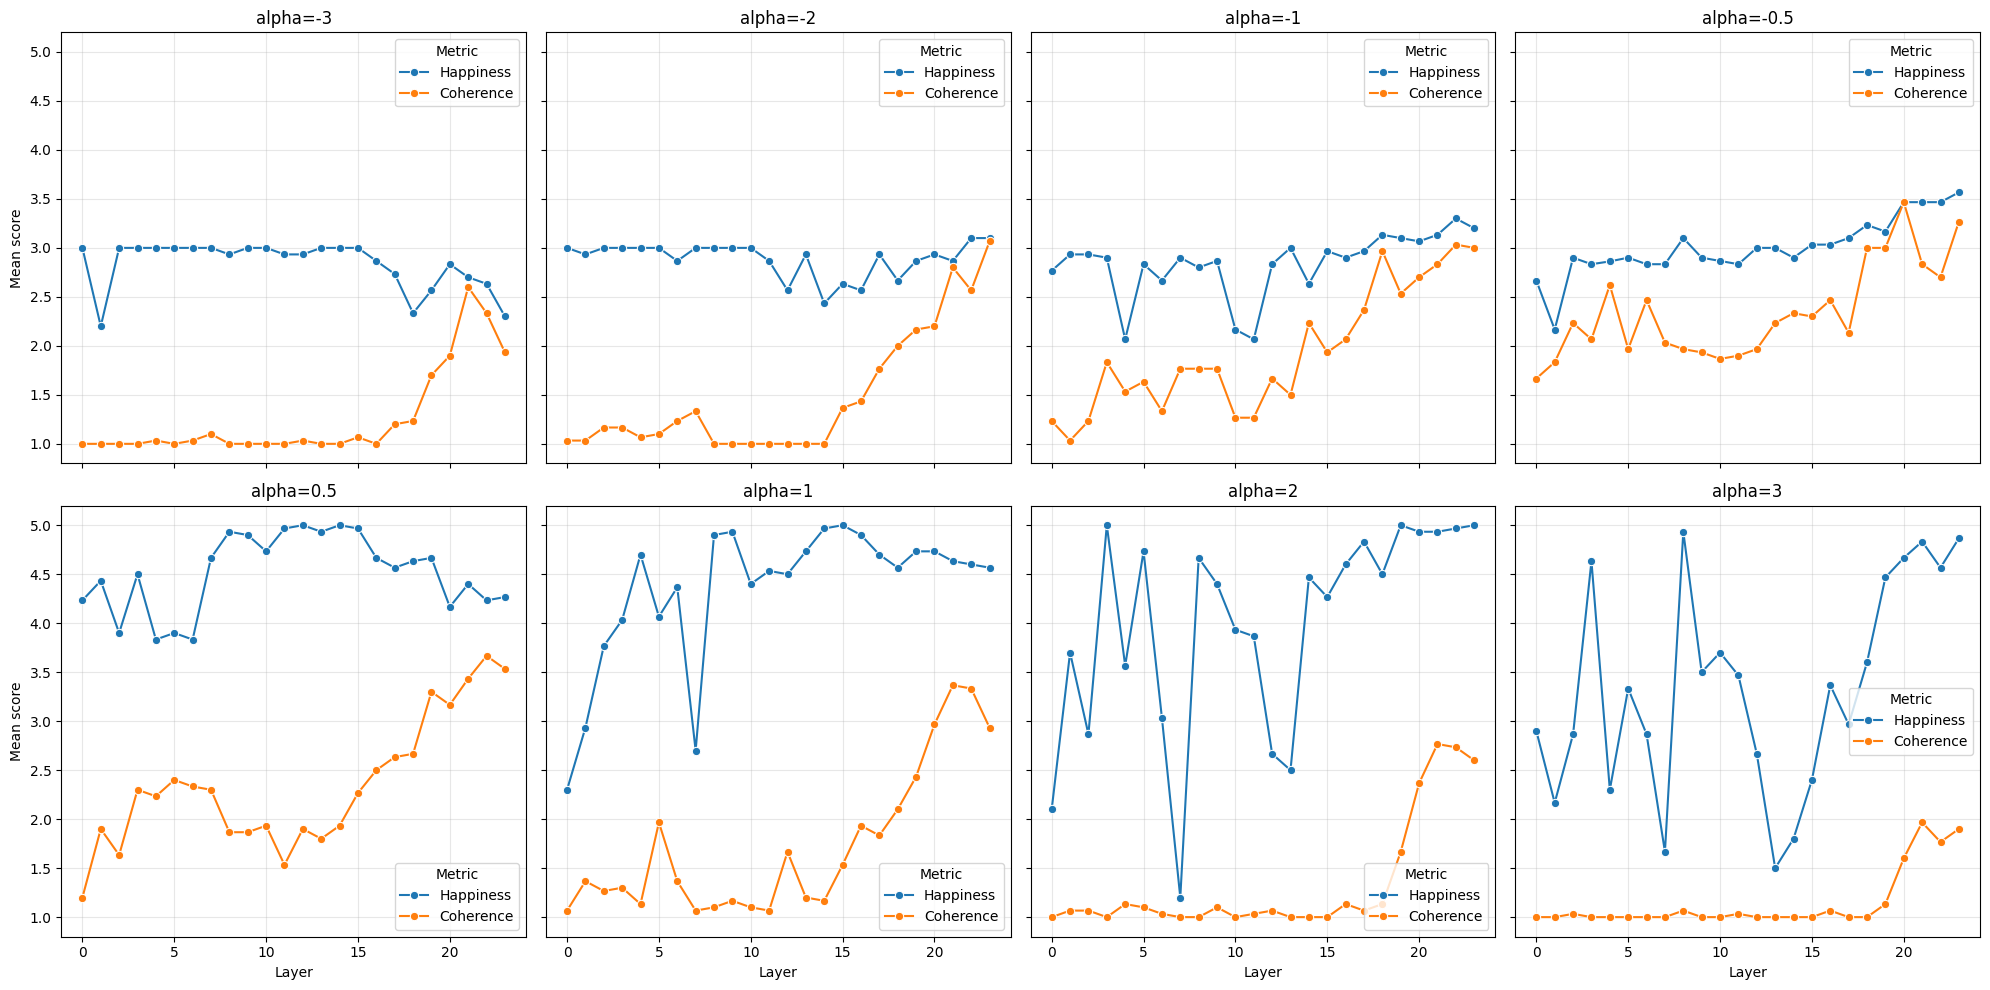

In [29]:
plot_agg = agg[agg["alpha"] != 0].copy()

best_happiness = plot_agg.loc[plot_agg["happiness_mean"].idxmax(), ["layer", "alpha", "happiness_mean", "happiness_std"]]
best_coherence = plot_agg.loc[plot_agg["coherence_mean"].idxmax(), ["layer", "alpha", "coherence_mean", "coherence_std"]]

print("Best happiness combination:")
print(best_happiness.to_string())
print()
print("Best coherence combination:")
print(best_coherence.to_string())
print()

ranked = plot_agg.copy()
ranked["happiness_norm"] = (ranked["happiness_mean"] - ranked["happiness_mean"].min()) / (ranked["happiness_mean"].max() - ranked["happiness_mean"].min())
ranked["coherence_norm"] = (ranked["coherence_mean"] - ranked["coherence_mean"].min()) / (ranked["coherence_mean"].max() - ranked["coherence_mean"].min())
ranked["combined_score"] = 0.5 * ranked["happiness_norm"] + 0.5 * ranked["coherence_norm"]
print("Top 10 combinations by balanced score:")
print(ranked.sort_values("combined_score", ascending=False).head(10)[["layer", "alpha", "happiness_mean", "coherence_mean", "combined_score"]].to_string(index=False))
alpha_values = sorted(plot_agg["alpha"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True, sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, alpha in zip(axes, alpha_values):
    alpha_data = plot_agg[plot_agg["alpha"] == alpha].sort_values("layer")
    sns.lineplot(data=alpha_data, x="layer", y="happiness_mean", marker="o", ax=ax, label="Happiness")
    sns.lineplot(data=alpha_data, x="layer", y="coherence_mean", marker="o", ax=ax, label="Coherence")
    ax.set_title(f"alpha={alpha:g}")
    ax.set_ylabel("Mean score")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Metric")

for ax in axes:
    ax.set_xlabel("Layer")
plt.tight_layout()

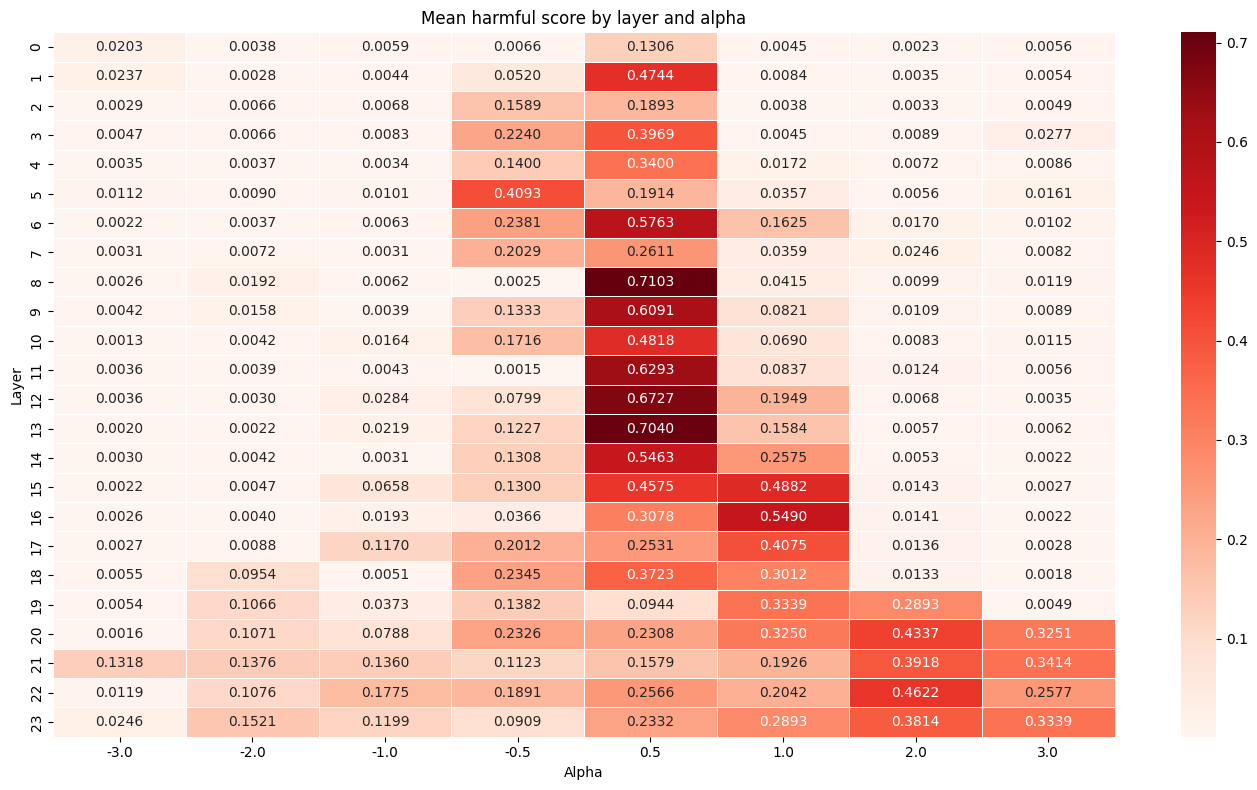

In [ ]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

harmful_scores = pd.read_csv("data/harm_responses_judged.csv")


def parse_harmful_score(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    if isinstance(value, (list, tuple, np.ndarray)):
        return float(value[0]) if len(value) > 0 else np.nan

    if isinstance(value, str):
        value = value.strip()
        if value == "":
            return np.nan

        try:
            parsed = ast.literal_eval(value)
        except Exception:
            try:
                return float(value)
            except Exception:
                return np.nan

        if isinstance(parsed, (list, tuple, np.ndarray)):
            return float(parsed[0]) if len(parsed) > 0 else np.nan

        try:
            return float(parsed)
        except Exception:
            return np.nan

    return np.nan


harmful_df = harmful_scores.copy()
harmful_df["harmful_score_num"] = harmful_df["harmful_score"].apply(parse_harmful_score)

summary = (
    harmful_df
    .groupby(["layer", "alpha"], as_index=False)
    .agg(
        mean_harmful_score=("harmful_score_num", "mean"),
        std_harmful_score=("harmful_score_num", "std"),
        n=("harmful_score_num", "count"),
    )
    .sort_values(["layer", "alpha"])
)

pivot_mean = summary.pivot(index="layer", columns="alpha", values="mean_harmful_score")

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_mean,
    cmap="Reds",
    annot=True,
    fmt=".4f",
    linewidths=0.5,
)

plt.title("Mean harmful score by layer and alpha")
plt.xlabel("Alpha")
plt.ylabel("Layer")
plt.tight_layout()
plt.show()

In [38]:
ablation_df=pd.read_csv("data/directional_ablation_judge_results.csv")

In [41]:
ablation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prompt_id              45 non-null     int64  
 1   prompt                 45 non-null     str    
 2   response               45 non-null     str    
 3   judge_raw              45 non-null     str    
 4   happiness_score        45 non-null     int64  
 5   coherence_score        41 non-null     float64
 6   happiness_explanation  45 non-null     str    
 7   coherence_explanation  45 non-null     str    
dtypes: float64(1), int64(2), str(5)
memory usage: 2.9 KB


In [34]:
judged_responses.info()

<class 'pandas.DataFrame'>
RangeIndex: 5790 entries, 0 to 5789
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prompt_id              5790 non-null   int64  
 1   prompt                 5790 non-null   str    
 2   layer                  5790 non-null   int64  
 3   alpha                  5790 non-null   float64
 4   response               5790 non-null   str    
 5   judge_raw              5790 non-null   str    
 6   happiness_score        5789 non-null   float64
 7   coherence_score        5789 non-null   float64
 8   happiness_explanation  5789 non-null   str    
 9   coherence_explanation  5789 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 452.5 KB


Ablation vs baseline prompt-wise comparison:
 baseline_prompt_id  ablation_prompt_id  baseline_happiness  ablation_happiness
                  0                  15                 4.0                   3
                  1                  16                 3.0                   3
                  2                  17                 4.0                   3
                  3                  18                 3.0                   3
                  4                  19                 4.0                   3
                  5                  20                 4.0                   4
                  6                  21                 4.0                   5
                  7                  22                 3.0                   4
                  8                  23                 5.0                   3
                  9                  24                 4.0                   3
                 10                  25                 4.0                

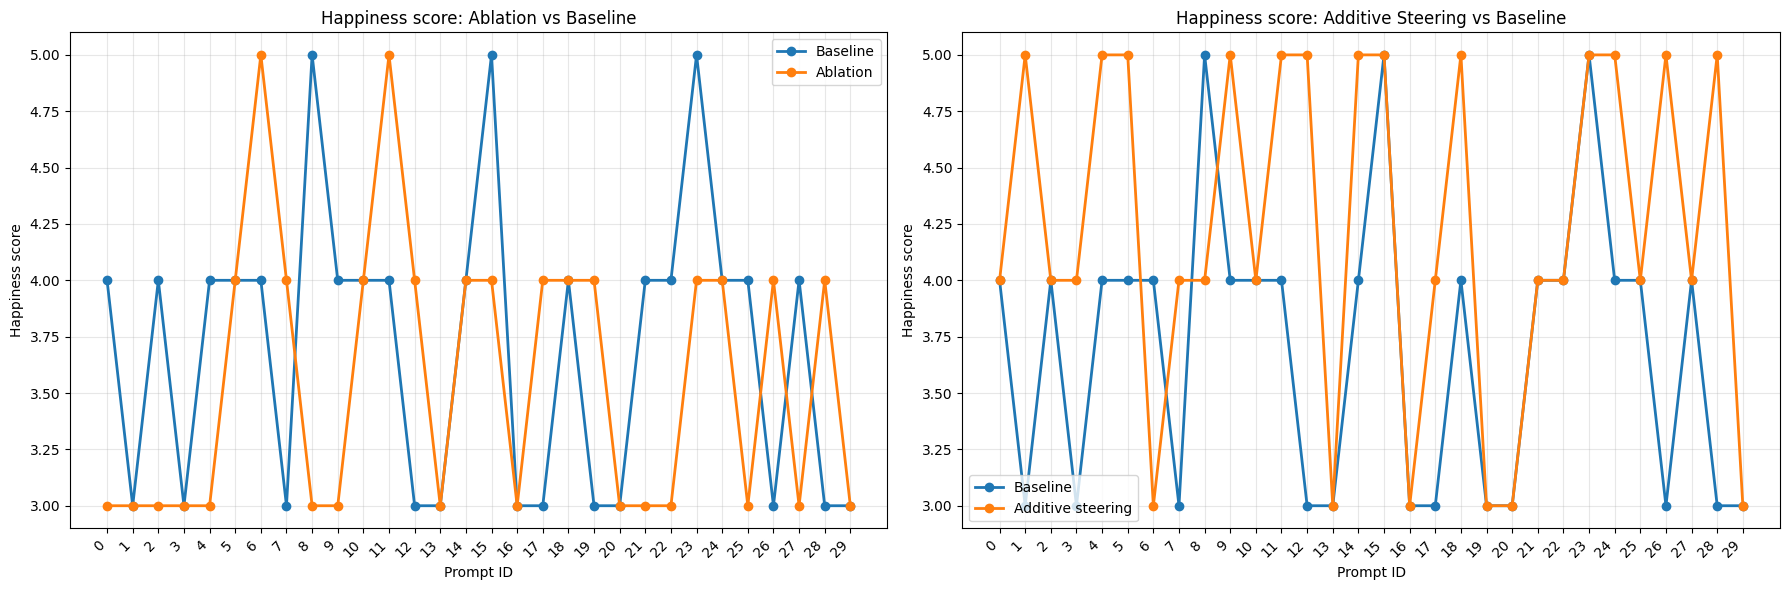

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline: alpha 0, layer -1 from judged_responses
baseline = judged_responses[
    (np.isclose(judged_responses["alpha"], 0)) &
    (judged_responses["layer"] == -1)
].copy()

# Ablation: last 30 rows from ablation_df
ablation_last30 = ablation_df.tail(30).copy()

# Additive steering: alpha 0.5, layer 22 from judged_responses
additive = judged_responses[
    (np.isclose(judged_responses["alpha"], 0.5)) &
    (judged_responses["layer"] == 22)
].copy()

# Make sure happiness scores are numeric
baseline["happiness_score"] = pd.to_numeric(baseline["happiness_score"], errors="coerce")
ablation_last30["happiness_score"] = pd.to_numeric(ablation_last30["happiness_score"], errors="coerce")
additive["happiness_score"] = pd.to_numeric(additive["happiness_score"], errors="coerce")

# Align by prompt so we compare the same prompts
ablation_cmp = (
    ablation_last30[["prompt_id", "prompt", "happiness_score"]]
    .rename(columns={
        "prompt_id": "ablation_prompt_id",
        "happiness_score": "ablation_happiness",
    })
    .merge(
        baseline[["prompt_id", "prompt", "happiness_score"]]
        .rename(columns={
            "prompt_id": "baseline_prompt_id",
            "happiness_score": "baseline_happiness",
        }),
        on="prompt",
        how="inner",
    )
    .sort_values("baseline_prompt_id")
    .reset_index(drop=True)
)

# Align additive steering and baseline by prompt as well
additive_cmp = (
    additive[["prompt_id", "prompt", "happiness_score"]]
    .rename(columns={
        "prompt_id": "additive_prompt_id",
        "happiness_score": "additive_happiness",
    })
    .merge(
        baseline[["prompt_id", "prompt", "happiness_score"]]
        .rename(columns={
            "prompt_id": "baseline_prompt_id",
            "happiness_score": "baseline_happiness",
        }),
        on="prompt",
        how="inner",
    )
    .sort_values("baseline_prompt_id")
    .reset_index(drop=True)
)

print("Ablation vs baseline prompt-wise comparison:")
print(ablation_cmp[["baseline_prompt_id", "ablation_prompt_id", "baseline_happiness", "ablation_happiness"]].to_string(index=False))
print()
print("Additive steering vs baseline prompt-wise comparison:")
print(additive_cmp[["baseline_prompt_id", "additive_prompt_id", "baseline_happiness", "additive_happiness"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)

# Plot 1: Ablation vs baseline
x1 = np.arange(len(ablation_cmp))
axes[0].plot(x1, ablation_cmp["baseline_happiness"], marker="o", linewidth=2, label="Baseline")
axes[0].plot(x1, ablation_cmp["ablation_happiness"], marker="o", linewidth=2, label="Ablation")
axes[0].set_title("Happiness score: Ablation vs Baseline")
axes[0].set_xlabel("Prompt ID")
axes[0].set_ylabel("Happiness score")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(ablation_cmp["baseline_prompt_id"].astype(str), rotation=45, ha="right")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Additive steering vs baseline
x2 = np.arange(len(additive_cmp))
axes[1].plot(x2, additive_cmp["baseline_happiness"], marker="o", linewidth=2, label="Baseline")
axes[1].plot(x2, additive_cmp["additive_happiness"], marker="o", linewidth=2, label="Additive steering")
axes[1].set_title("Happiness score: Additive Steering vs Baseline")
axes[1].set_xlabel("Prompt ID")
axes[1].set_ylabel("Happiness score")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(additive_cmp["baseline_prompt_id"].astype(str), rotation=45, ha="right")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()